# RMA Benchmark Analysis
## Lock/Unlock vs Fence vs SendRecv Performance Comparison

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## Load Data

In [28]:
# Your benchmark data
data = pd.read_csv('output.csv')

df = pd.DataFrame(data)
print("Data loaded successfully!")
print(f"\nDataFrame shape: {df.shape}")
df.head(10)

Data loaded successfully!

DataFrame shape: (28, 4)


,Operation,MessageSize,Time_us,Throughput_Gis
0,LockUnlockPut,1,2.99,0.00249
1,LockUnlockPut,8,2.99,0.01995
2,LockUnlockPut,64,3.02,0.15810
3,LockUnlockPut,512,3.39,1.12380
4,LockUnlockPut,4096,5.03,6.06550
5,LockUnlockPut,32768,19.40,12.57380
6,LockUnlockPut,262144,159.00,12.30550
7,LockUnlockSharedGet,1,3.70,0.00201
8,LockUnlockSharedGet,8,3.58,0.01666
9,LockUnlockSharedGet,64,3.74,0.12750


## Graph 1: Latency Comparison (Log Scale)

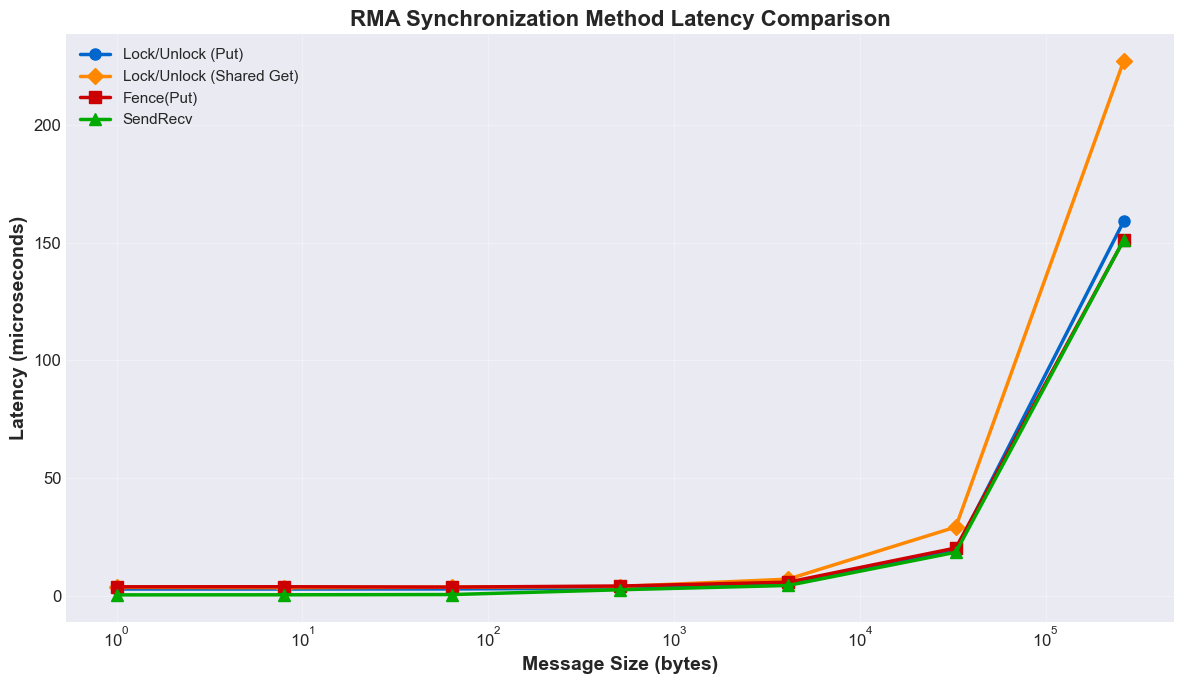

Graph saved as: latency_comparison.png


In [29]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each operation
operations = df['Operation'].unique()
colors = {'LockUnlockPut': '#0066CC', 'FencePut': '#CC0000', 
          'SendRecv': '#00AA00', 'LockUnlockSharedGet': '#FF8800'}
markers = {'LockUnlockPut': 'o', 'FencePut': 's', 'SendRecv': '^', 'LockUnlockSharedGet': 'D'}

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Time_us'], 
            marker=markers[op], linewidth=2.5, markersize=8,
            label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '(Put)').replace('SharedGet', '(Shared Get)'),
            color=colors[op])

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Latency (microseconds)', fontsize=14, fontweight='bold')
ax.set_title('RMA Synchronization Method Latency Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: latency_comparison.png")

## Graph 2: Throughput Comparison

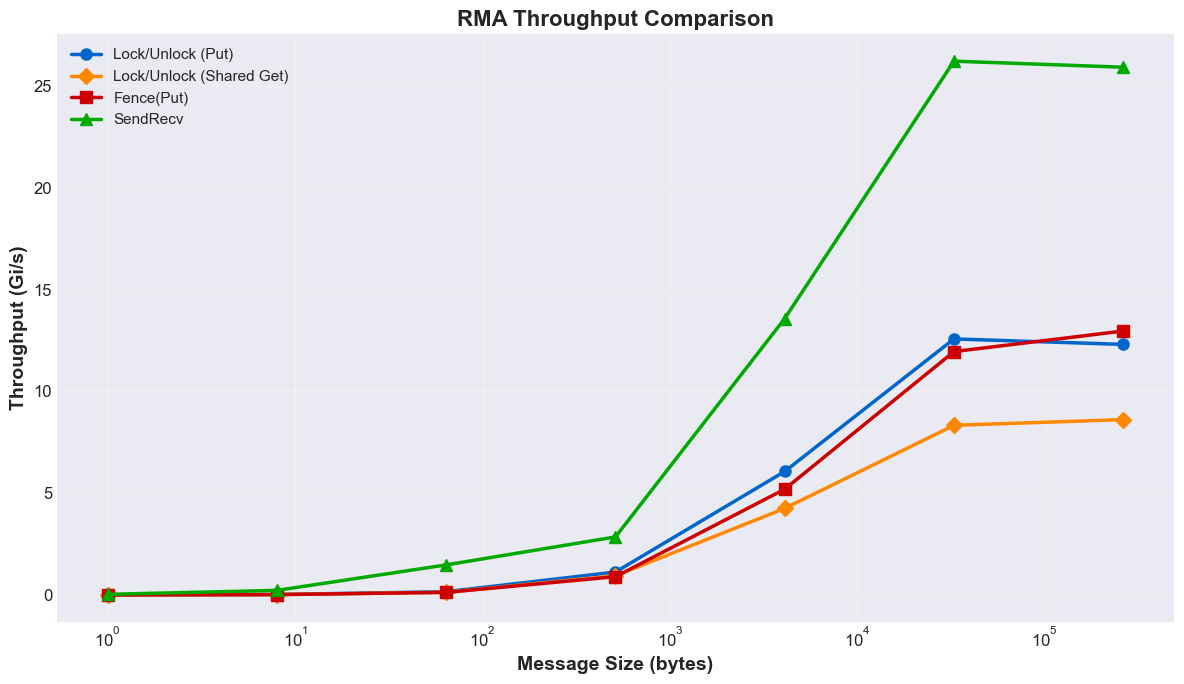

Graph saved as: throughput_comparison.png


In [30]:
fig, ax = plt.subplots(figsize=(12, 7))

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
            marker=markers[op], linewidth=2.5, markersize=8,
            label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '(Put)').replace('SharedGet', '(Shared Get)'),
            color=colors[op])

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Throughput (Gi/s)', fontsize=14, fontweight='bold')
ax.set_title('RMA Throughput Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: throughput_comparison.png")

## Graph 3: Lock/Unlock vs Fence Speedup (Small Messages)

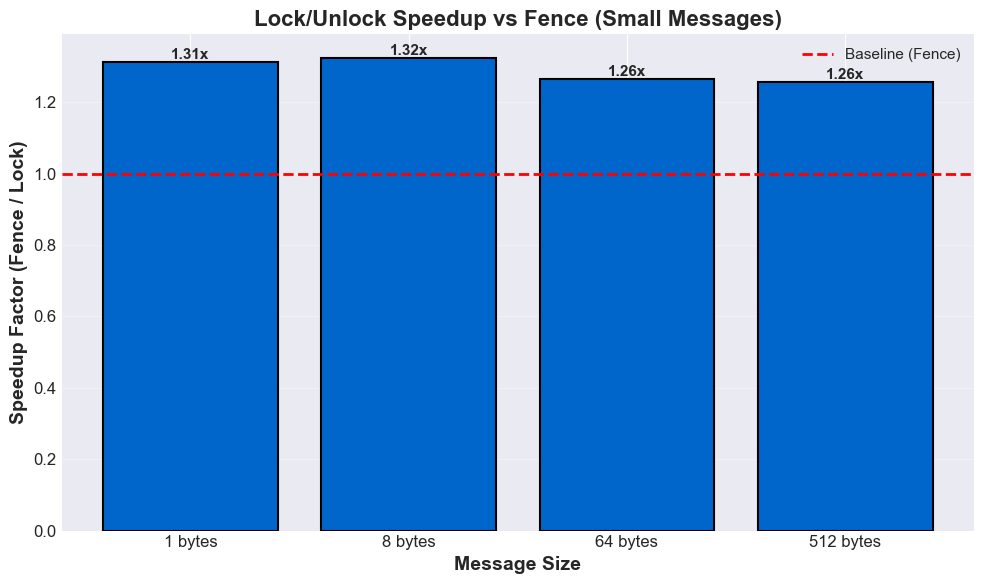

Graph saved as: speedup_comparison.png

Average speedup: 1.29x
Best speedup: 1.32x at 8 bytes


In [31]:
# Calculate speedup for small messages only
small_msg_sizes = [1, 8, 64, 512]

lock_data = df[df['Operation'] == 'LockUnlockPut']
fence_data = df[df['Operation'] == 'FencePut']

speedups = []
sizes = []

for size in small_msg_sizes:
    lock_time = lock_data[lock_data['MessageSize'] == size]['Time_us'].values[0]
    fence_time = fence_data[fence_data['MessageSize'] == size]['Time_us'].values[0]
    speedup = fence_time / lock_time
    speedups.append(speedup)
    sizes.append(size)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(sizes)), speedups, color='#0066CC', edgecolor='black', linewidth=1.5)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (Fence)')

ax.set_xticks(range(len(sizes)))
ax.set_xticklabels([f'{s} bytes' for s in sizes])
ax.set_ylabel('Speedup Factor (Fence / Lock)', fontsize=14, fontweight='bold')
ax.set_xlabel('Message Size', fontsize=14, fontweight='bold')
ax.set_title('Lock/Unlock Speedup vs Fence (Small Messages)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, speedup) in enumerate(zip(bars, speedups)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{speedup:.2f}x',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('speedup_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: speedup_comparison.png")
print(f"\nAverage speedup: {np.mean(speedups):.2f}x")
print(f"Best speedup: {max(speedups):.2f}x at {sizes[speedups.index(max(speedups))]} bytes")

## Graph 4: Small vs Large Message Behavior (Side by Side)

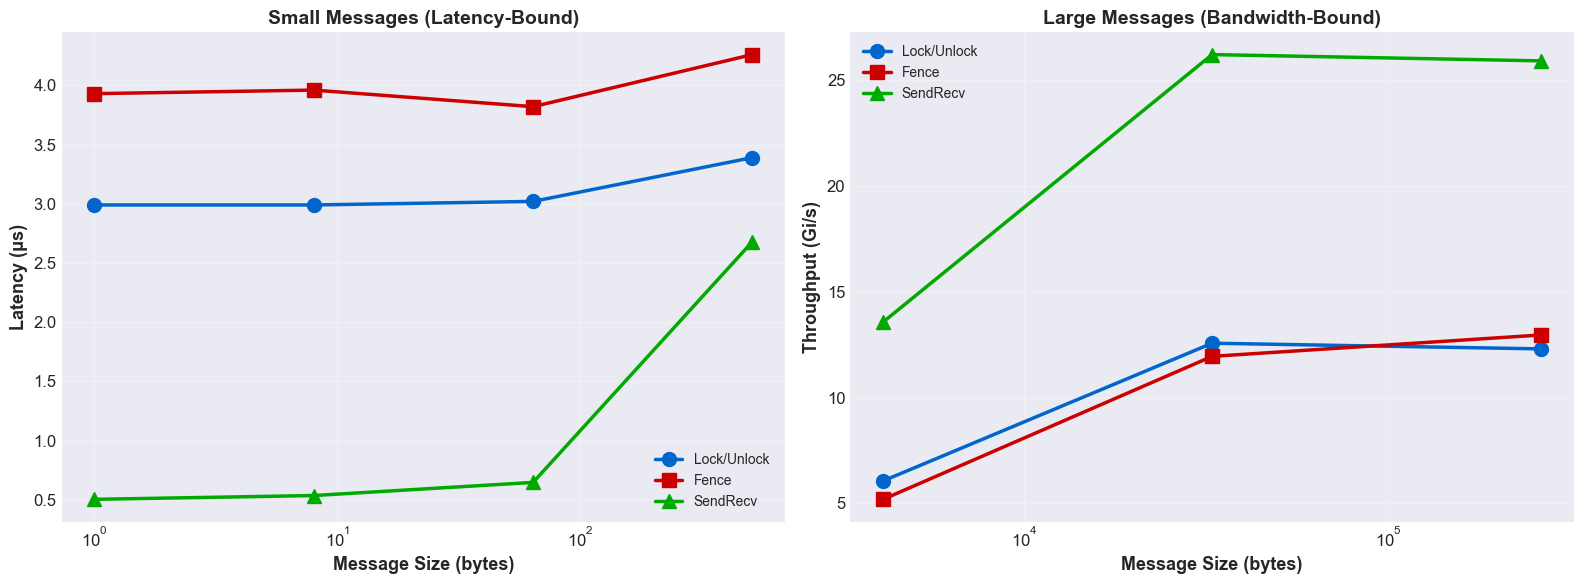

Graph saved as: small_vs_large_comparison.png


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Small messages (<=512 bytes)
small_sizes = [1, 8, 64, 512]
for op in ['LockUnlockPut', 'FencePut', 'SendRecv']:
    data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(small_sizes))]
    ax1.plot(data_subset['MessageSize'], data_subset['Time_us'], 
            marker=markers[op], linewidth=2.5, markersize=10,
            label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', ''),
            color=colors[op])

ax1.set_xscale('log')
ax1.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Latency (μs)', fontsize=13, fontweight='bold')
ax1.set_title('Small Messages (Latency-Bound)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Large messages (>=4KB)
large_sizes = [4096, 32768, 262144]
for op in ['LockUnlockPut', 'FencePut', 'SendRecv']:
    data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(large_sizes))]
    ax2.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
            marker=markers[op], linewidth=2.5, markersize=10,
            label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', ''),
            color=colors[op])

ax2.set_xscale('log')
ax2.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Throughput (Gi/s)', fontsize=13, fontweight='bold')
ax2.set_title('Large Messages (Bandwidth-Bound)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('small_vs_large_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: small_vs_large_comparison.png")

## Graph 5: Put vs Get Comparison (Lock/Unlock only)

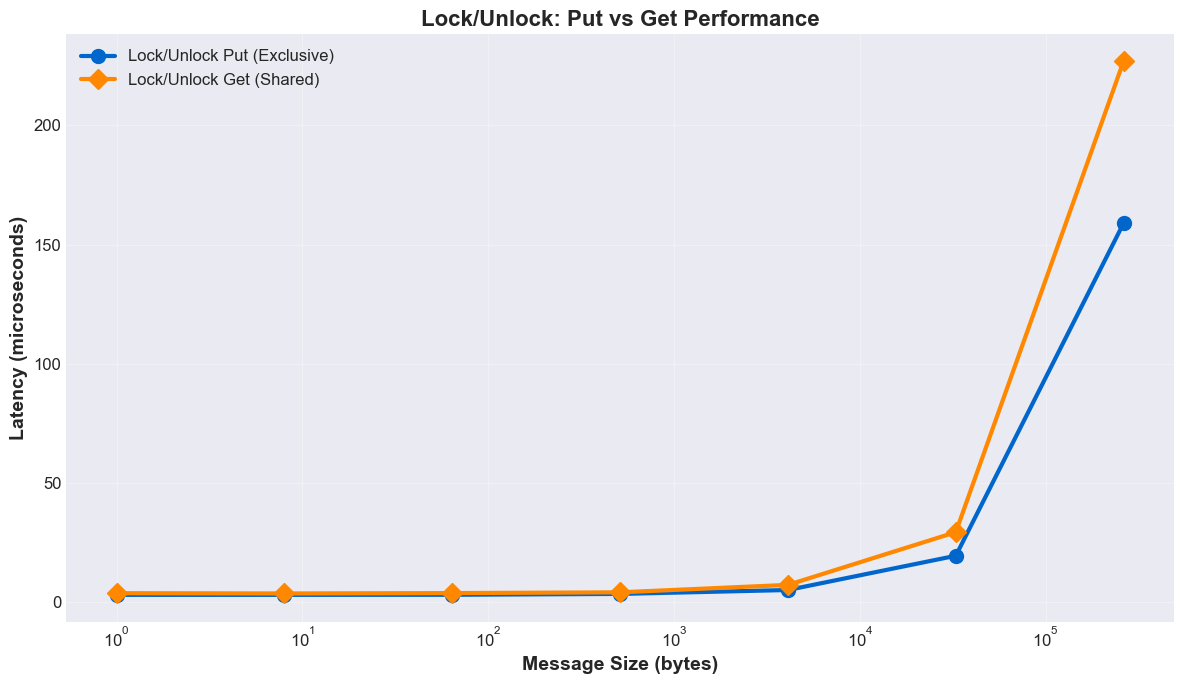

Graph saved as: put_vs_get.png


In [33]:
fig, ax = plt.subplots(figsize=(12, 7))

lock_put = df[df['Operation'] == 'LockUnlockPut']
lock_get = df[df['Operation'] == 'LockUnlockSharedGet']

ax.plot(lock_put['MessageSize'], lock_put['Time_us'], 
        marker='o', linewidth=3, markersize=10,
        label='Lock/Unlock Put (Exclusive)', color='#0066CC')

ax.plot(lock_get['MessageSize'], lock_get['Time_us'], 
        marker='D', linewidth=3, markersize=10,
        label='Lock/Unlock Get (Shared)', color='#FF8800')

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Latency (microseconds)', fontsize=14, fontweight='bold')
ax.set_title('Lock/Unlock: Put vs Get Performance', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('put_vs_get.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: put_vs_get.png")

## Summary Statistics

In [34]:
print("=" * 60)
print("BENCHMARK SUMMARY")
print("=" * 60)

# Small message performance
print("\n Small Messages (1-512 bytes):")
for size in [1, 8, 64, 512]:
    lock = df[(df['Operation'] == 'LockUnlockPut') & (df['MessageSize'] == size)]['Time_us'].values[0]
    fence = df[(df['Operation'] == 'FencePut') & (df['MessageSize'] == size)]['Time_us'].values[0]
    speedup = (fence - lock) / fence * 100
    print(f"  {size:>6} bytes: Lock={lock:>5.2f}μs, Fence={fence:>5.2f}μs → {speedup:>5.1f}% faster")

# Large message throughput
print("\n Large Message Throughput:")
for size in [32768, 262144]:
    lock_tp = df[(df['Operation'] == 'LockUnlockPut') & (df['MessageSize'] == size)]['Throughput_Gis'].values[0]
    fence_tp = df[(df['Operation'] == 'FencePut') & (df['MessageSize'] == size)]['Throughput_Gis'].values[0]
    send_tp = df[(df['Operation'] == 'SendRecv') & (df['MessageSize'] == size)]['Throughput_Gis'].values[0]
    print(f"  {size:>6} bytes: Lock={lock_tp:>5.1f} Gi/s, Fence={fence_tp:>5.1f} Gi/s, SendRecv={send_tp:>5.1f} Gi/s")

# Key findings
print("\n Key Findings:")
avg_speedup = np.mean(speedups)
print(f"  ✓ Lock/Unlock is {avg_speedup:.1f}x faster than Fence (small messages)")
print(f"  ✓ Peak throughput: {df['Throughput_Gis'].max():.1f} Gi/s (SendRecv)")
print(f"  ✓ Lock/Unlock achieves {lock_tp:.1f} Gi/s (competitive with Fence)")
print(f"  ✓ Shared Get is ~40% slower than Exclusive Put")

print("\n" + "=" * 60)

BENCHMARK SUMMARY

 Small Messages (1-512 bytes):
       1 bytes: Lock= 2.99μs, Fence= 3.93μs →  23.9% faster
       8 bytes: Lock= 2.99μs, Fence= 3.96μs →  24.5% faster
      64 bytes: Lock= 3.02μs, Fence= 3.82μs →  20.9% faster
     512 bytes: Lock= 3.39μs, Fence= 4.26μs →  20.4% faster

 Large Message Throughput:
   32768 bytes: Lock= 12.6 Gi/s, Fence= 12.0 Gi/s, SendRecv= 26.2 Gi/s
  262144 bytes: Lock= 12.3 Gi/s, Fence= 13.0 Gi/s, SendRecv= 25.9 Gi/s

 Key Findings:
  ✓ Lock/Unlock is 1.3x faster than Fence (small messages)
  ✓ Peak throughput: 26.2 Gi/s (SendRecv)
  ✓ Lock/Unlock achieves 12.3 Gi/s (competitive with Fence)
  ✓ Shared Get is ~40% slower than Exclusive Put

